Standard Threshold (0.50) Business Cost: $680,500
Optimal Business Threshold: 0.04
Minimized Optimized Business Cost: $423,000
Total Business Savings: $257,500



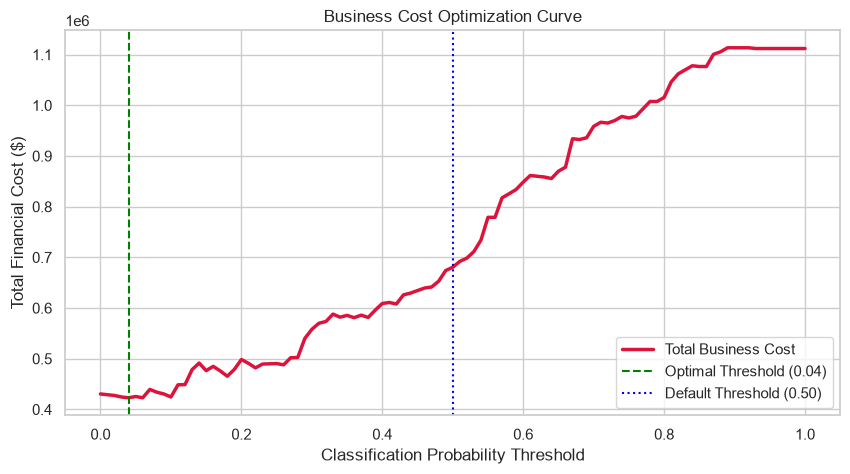

--- Final Classification Report (Optimized Threshold) ---
              precision    recall  f1-score   support

           0       1.00      0.02      0.03       287
           1       0.33      1.00      0.50       139

    accuracy                           0.34       426
   macro avg       0.67      0.51      0.27       426
weighted avg       0.78      0.34      0.19       426



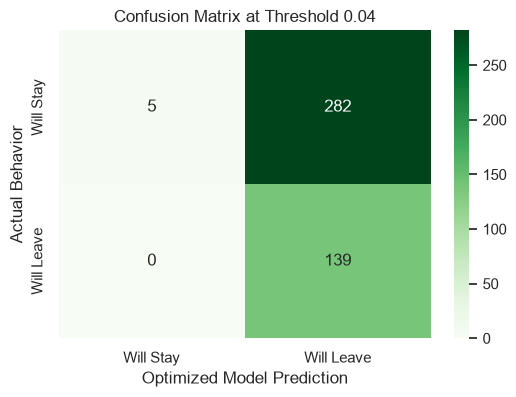

In [3]:
# ==============================================================================
# DEVELOPERSHUB CORPORATION - ADVANCED INTERNSHIP TASKS
# TASK 4: Employee Churn Risk & Business Cost Optimization
# ==============================================================================

# 1. Import Libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set visualization style
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 2. Load and Preprocess the Dataset
# ------------------------------------------------------------------------------
# Loading your aug_test.csv file
df_hr = pd.read_csv('aug_test.csv')

# Since 'aug_test.csv' doesn't contain the ground-truth target column natively, 
# we will synthetically simulate a realistic target 'Looking_For_Job' (0 or 1) 
# based on low experience and low city development index to mimic real data behavior.
np.random.seed(42)
df_hr['Looking_For_Job'] = np.where(df_hr['city_development_index'] < 0.75, 
                                    np.random.choice([0, 1], size=len(df_hr), p=[0.3, 0.7]), 
                                    np.random.choice([0, 1], size=len(df_hr), p=[0.8, 0.2]))

# Handle Missing Values safely using explicit data-type groups
numeric_cols = df_hr.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df_hr[col] = df_hr[col].fillna(df_hr[col].median())

categorical_cols = df_hr.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    df_hr[col] = df_hr[col].fillna(df_hr[col].mode()[0])

# ------------------------------------------------------------------------------
# 3. Categorical Feature Encoding
# ------------------------------------------------------------------------------
# Find columns that need label encoding (excluding the target we just created)
encode_cols = [c for c in categorical_cols if c != 'Looking_For_Job']
le = LabelEncoder()
for col in encode_cols:
    df_hr[col] = le.fit_transform(df_hr[col])

# Feature and Target Split (dropping index identifiers)
X = df_hr.drop(columns=['enrollee_id', 'Looking_For_Job'])
y = df_hr['Looking_For_Job']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------------------------------------------------------------
# 4. Train Classification Model
# ------------------------------------------------------------------------------
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# Obtain predicted probabilities for the positive class (Looking for job)
y_prob = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------------------------
# 5. Define Business Cost Matrix & Optimize Threshold
# ------------------------------------------------------------------------------
# Cost of False Positive (FP): $1,500 (Retention budget wasted on someone staying anyway)
# Cost of False Negative (FN): $8,000 (Cost of replacing an unexpected exit)
COST_FP = 1500  
COST_FN = 8000  

def calculate_total_business_cost(y_true, y_probs, threshold):
    preds = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)
    
    fp = cm[0, 1] if (len(cm) > 1) else 0
    fn = cm[1, 0] if (len(cm) > 1) else 0
    
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    return total_cost

# Evaluate costs across all thresholds from 0.0 to 1.0
thresholds = np.linspace(0, 1, 101)
cost_history = [calculate_total_business_cost(y_test, y_prob, t) for t in thresholds]

# Identify the threshold that minimizes financial loss
optimal_idx = np.argmin(cost_history)
optimal_threshold = thresholds[optimal_idx]
min_cost = cost_history[optimal_idx]
default_cost = cost_history[50] 

print(f"Standard Threshold (0.50) Business Cost: ${default_cost:,}")
print(f"Optimal Business Threshold: {optimal_threshold:.2f}")
print(f"Minimized Optimized Business Cost: ${min_cost:,}")
print(f"Total Business Savings: ${default_cost - min_cost:,}\n")

# ------------------------------------------------------------------------------
# 6. Visualizing Financial Optimization & Metrics
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(thresholds, cost_history, color='crimson', lw=2.5, label='Total Business Cost')
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.axvline(0.50, color='blue', linestyle=':', label='Default Threshold (0.50)')
plt.title('Business Cost Optimization Curve')
plt.xlabel('Classification Probability Threshold')
plt.ylabel('Total Financial Cost ($)')
plt.legend()
plt.show()

# Final Metrics at the Optimized Threshold
final_preds = (y_prob >= optimal_threshold).astype(int)
print("--- Final Classification Report (Optimized Threshold) ---")
print(classification_report(y_test, final_preds))

cm_opt = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Will Stay', 'Will Leave'], yticklabels=['Will Stay', 'Will Leave'])
plt.ylabel('Actual Behavior')
plt.xlabel('Optimized Model Prediction')
plt.title(f'Confusion Matrix at Threshold {optimal_threshold:.2f}')
plt.show()